# # Comparacion clases en el espectro NIR de la clase seleccionada: Avionetas 

In [1]:
carpeta_avionetas_vedai = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\data_exploration\outputs\output_dataset_por_clases\cls_31_avionetas"


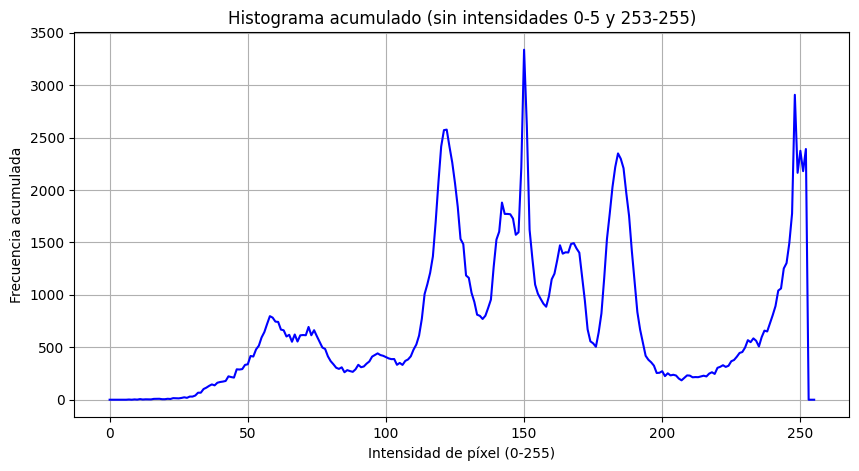

array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 2.000e+00, 0.000e+00, 3.000e+00, 1.000e+00, 6.000e+00,
       2.000e+00, 4.000e+00, 4.000e+00, 3.000e+00, 8.000e+00, 8.000e+00,
       9.000e+00, 5.000e+00, 5.000e+00, 9.000e+00, 7.000e+00, 1.500e+01,
       1.400e+01, 1.300e+01, 1.700e+01, 2.300e+01, 1.800e+01, 3.000e+01,
       3.000e+01, 4.000e+01, 6.700e+01, 6.700e+01, 1.020e+02, 1.150e+02,
       1.320e+02, 1.460e+02, 1.370e+02, 1.620e+02, 1.690e+02, 1.730e+02,
       1.790e+02, 2.230e+02, 2.160e+02, 2.110e+02, 2.900e+02, 2.880e+02,
       2.920e+02, 3.320e+02, 3.380e+02, 4.170e+02, 4.120e+02, 4.800e+02,
       5.150e+02, 5.940e+02, 6.450e+02, 7.230e+02, 7.970e+02, 7.830e+02,
       7.450e+02, 7.420e+02, 6.690e+02, 6.620e+02, 6.030e+02, 6.190e+02,
       5.530e+02, 6.220e+02, 5.550e+02, 6.140e+02, 6.170e+02, 6.150e+02,
       6.940e+02, 6.150e+02, 6.630e+02, 6.060e+02, 5.530e+02, 4.980e+02,
       4.840e+02, 4.140e+02, 3.680e+02, 3.380e+02, 

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def histograma_acumulado_carpeta(ruta_carpeta):
    # Inicializamos histograma acumulado (256 niveles de gris)
    hist_acumulado = np.zeros(256, dtype=np.float64)
    
    # Iteramos sobre cada archivo de la carpeta
    for archivo in os.listdir(ruta_carpeta):
        ruta_imagen = os.path.join(ruta_carpeta, archivo)
        
        # Verificamos que sea una imagen
        if os.path.isfile(ruta_imagen) and archivo.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')):
            # Leemos la imagen en escala de grises
            img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
            
            if img is not None:
                # Calculamos histograma de la imagen
                hist = cv2.calcHist([img], [0], None, [256], [0,256])
                hist_acumulado += hist.flatten()
    
    # 🔹 Borrar intensidades entre 0-5 y 253-255
    hist_acumulado[0:6] = 0     # Niveles 0 a 5
    hist_acumulado[253:256] = 0 # Niveles 253 a 255

    # Graficamos histograma acumulado modificado
    plt.figure(figsize=(10,5))
    plt.plot(hist_acumulado, color='blue')
    plt.title("Histograma acumulado (sin intensidades 0-5 y 253-255)")
    plt.xlabel("Intensidad de píxel (0-255)")
    plt.ylabel("Frecuencia acumulada")
    plt.grid(True)
    plt.show()

    return hist_acumulado

# Ejemplo de uso:
histograma_acumulado_carpeta(carpeta_avionetas_vedai)


Ahora vamos a entender como estan etiquetadas cada objeto dentro de cada imagen.

In [ ]:

ruta_anotaciones_json = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\formato_coco\result.json"
r_images = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\formato_coco\images"


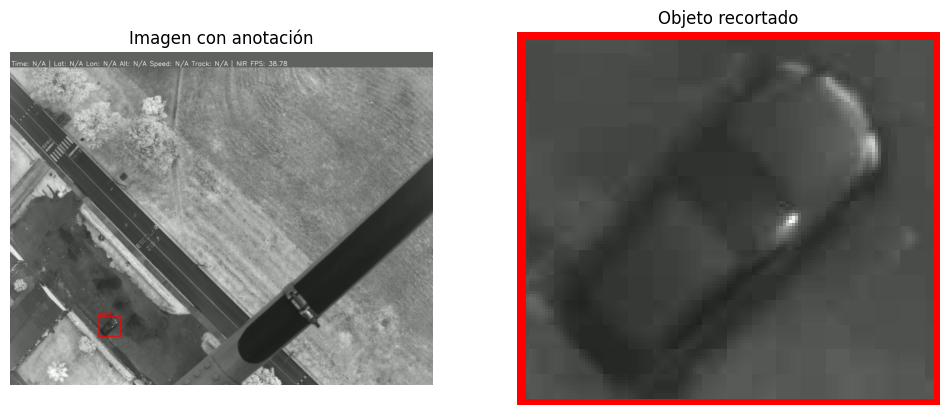

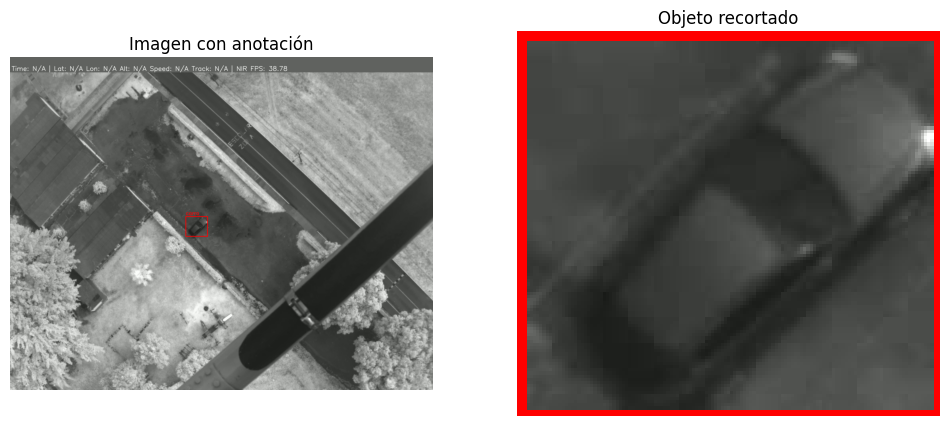

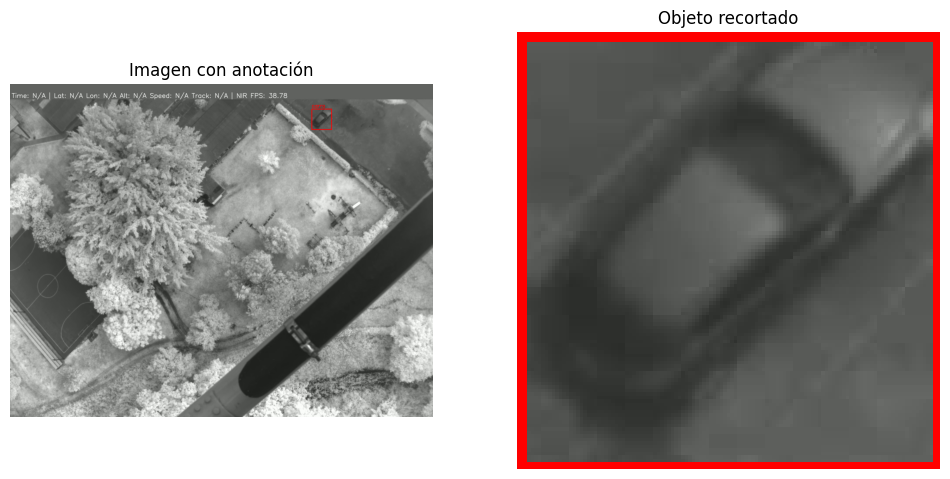

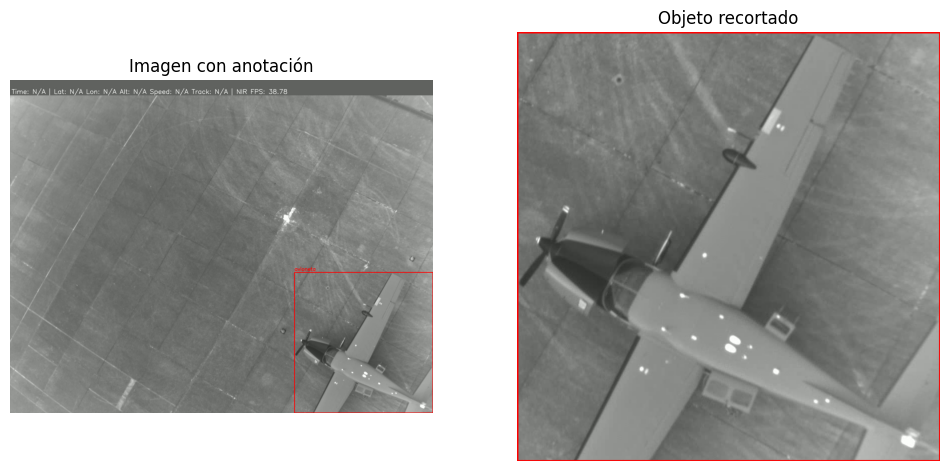

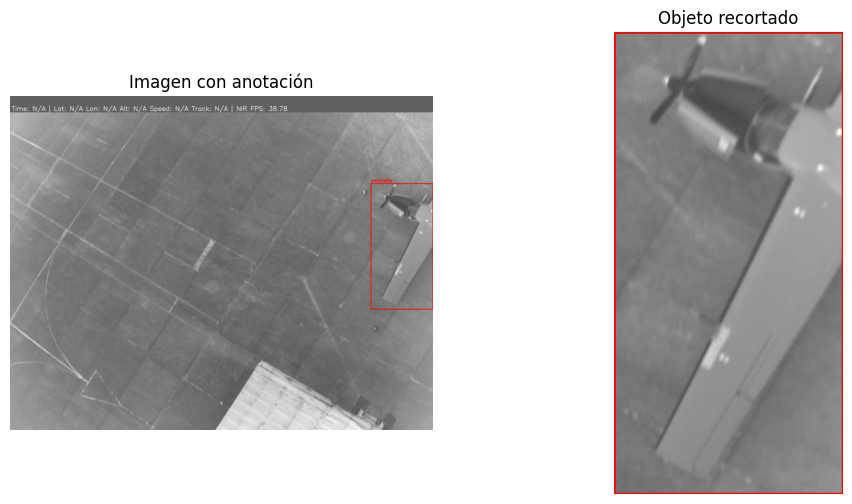

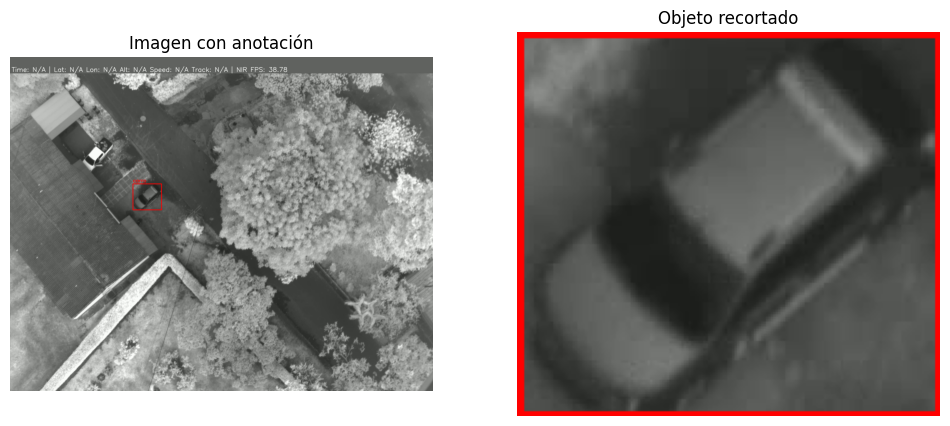

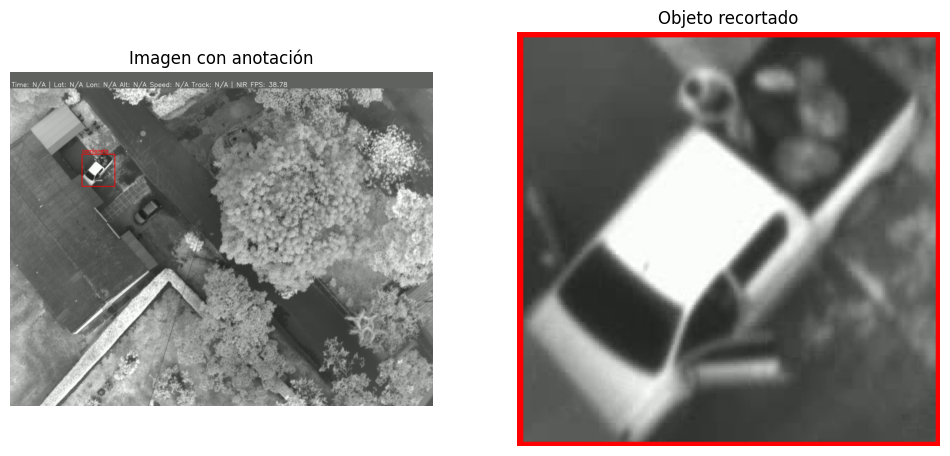

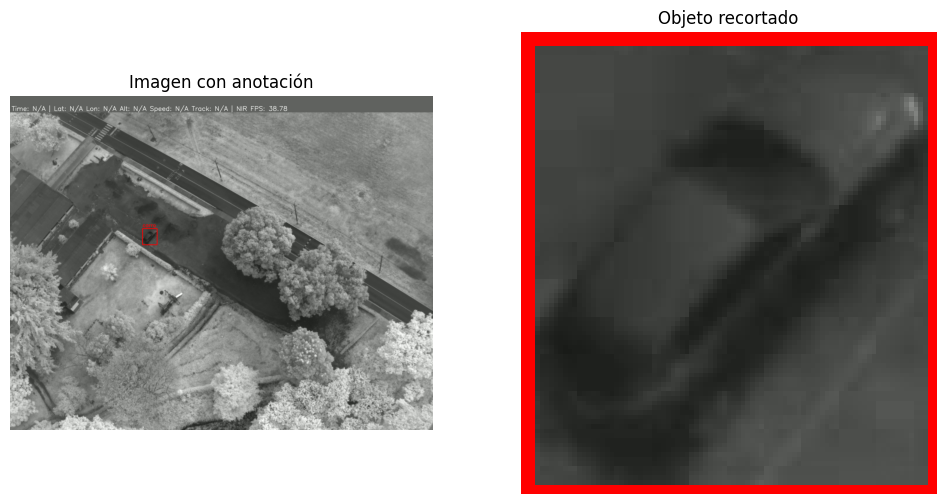

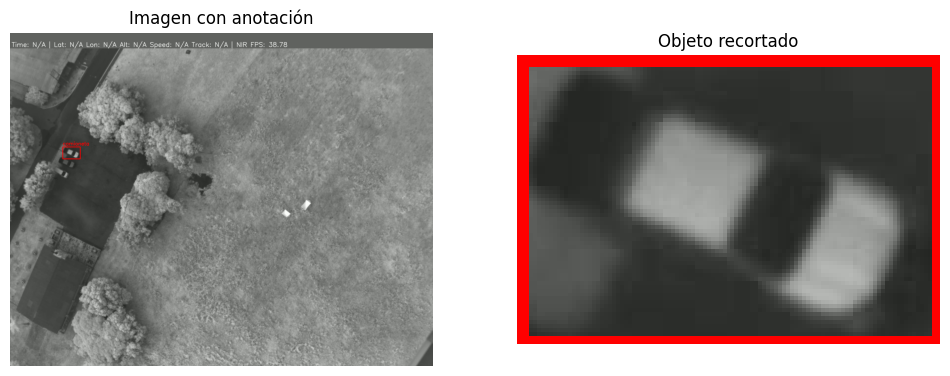

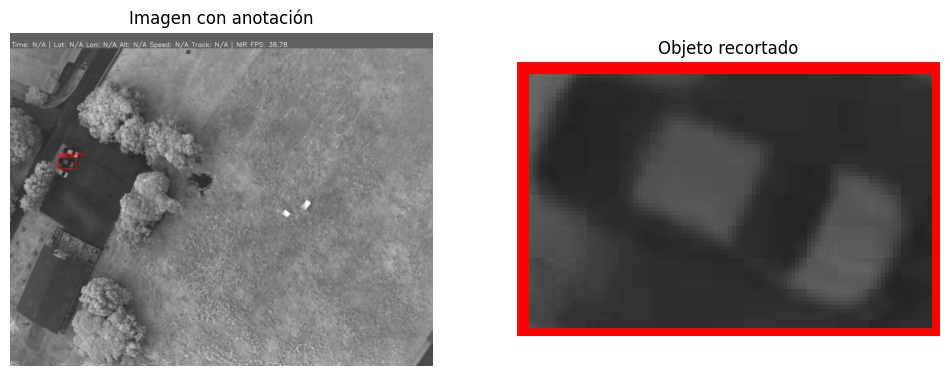

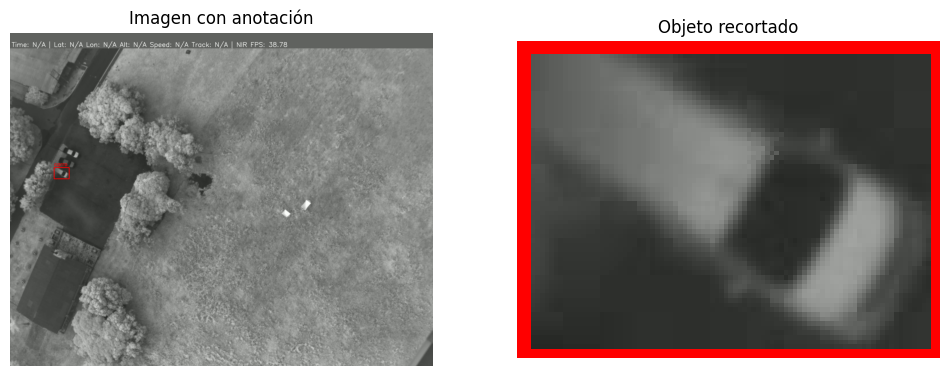

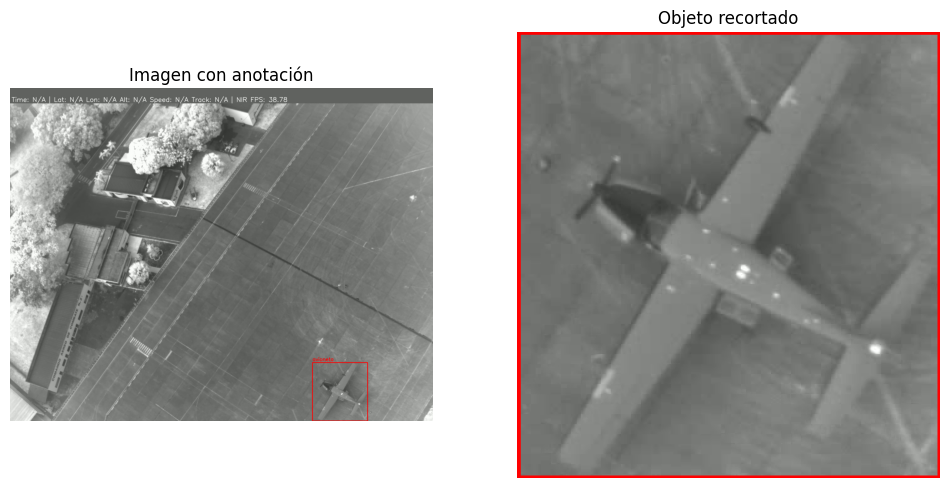

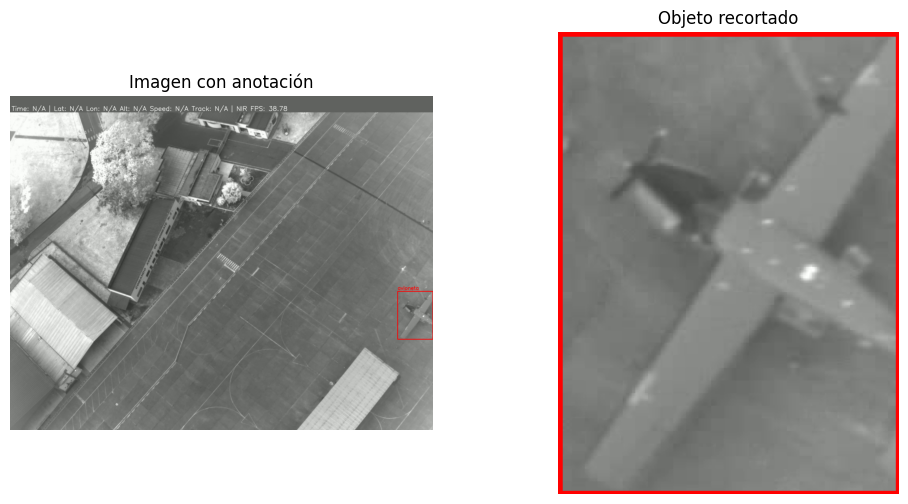

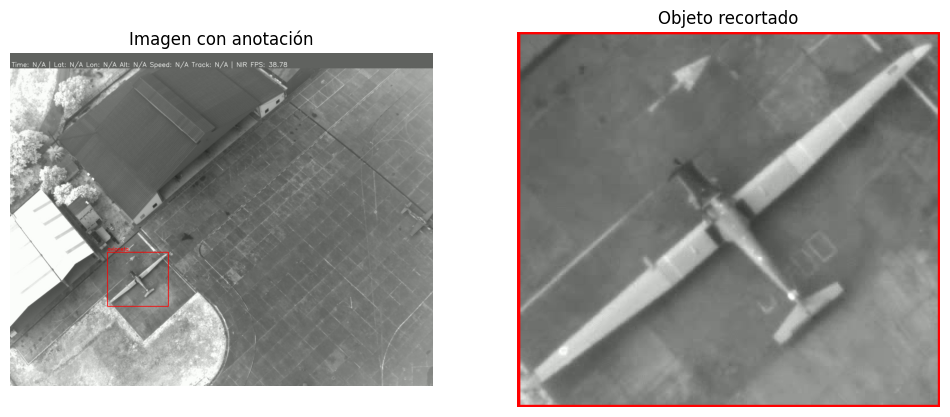

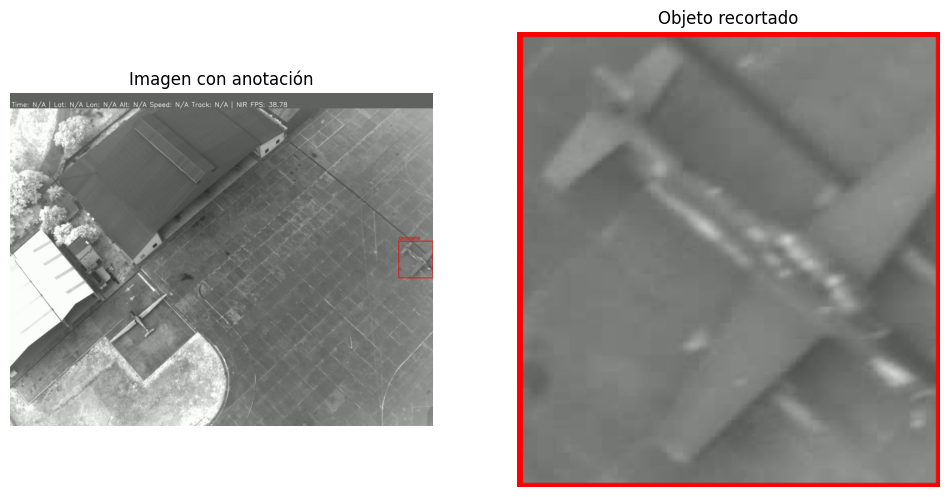

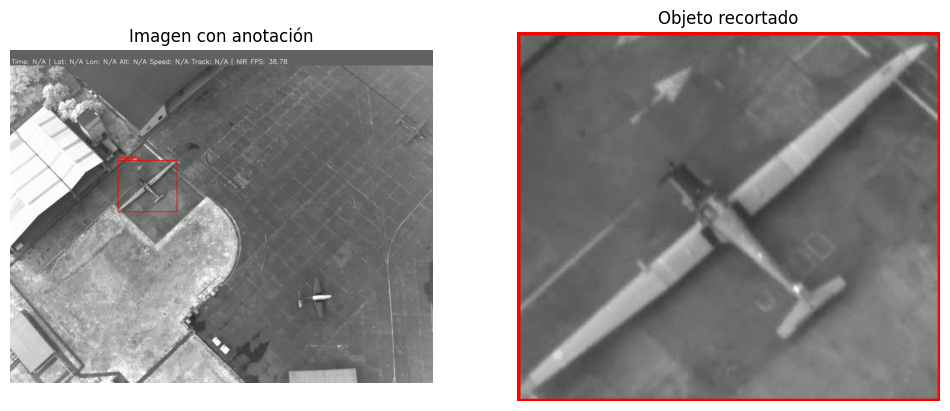

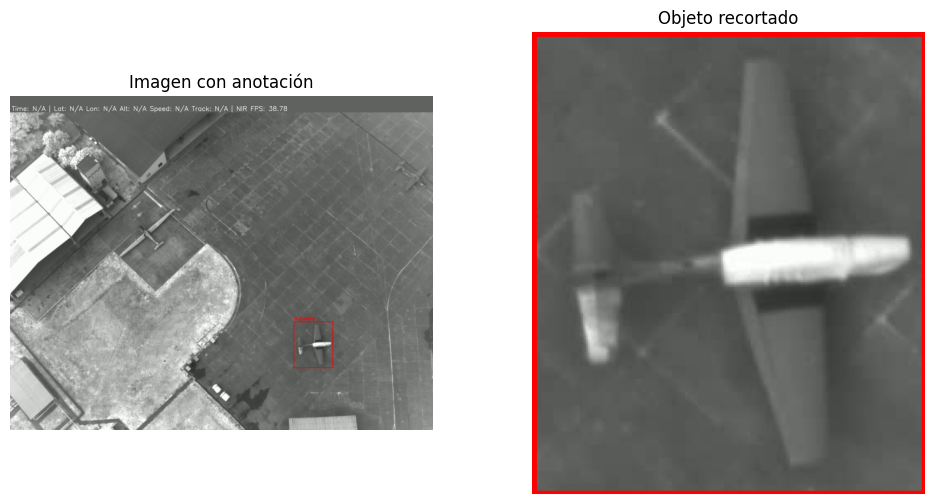

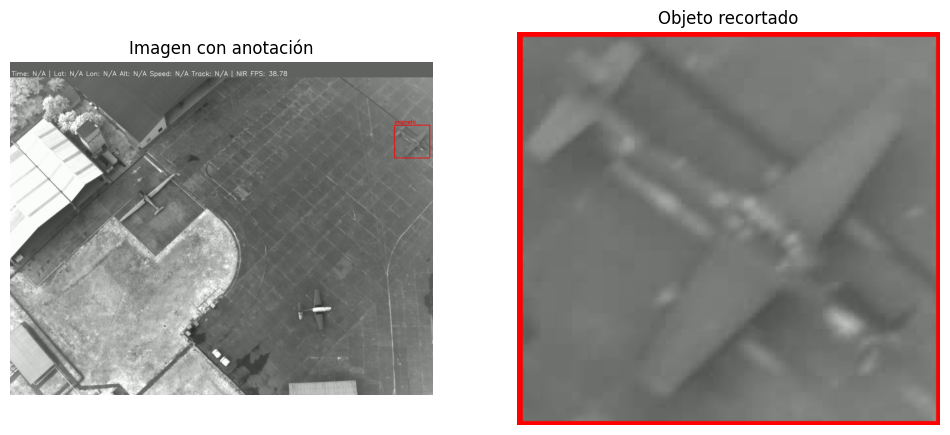

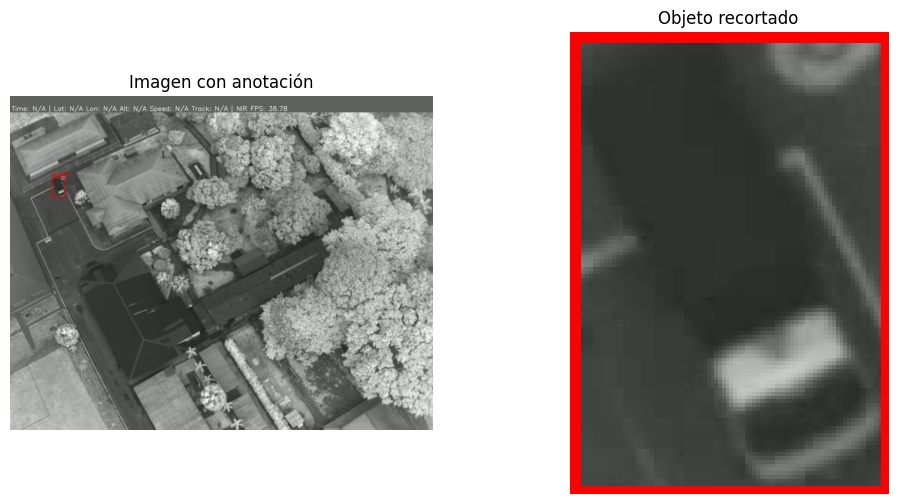

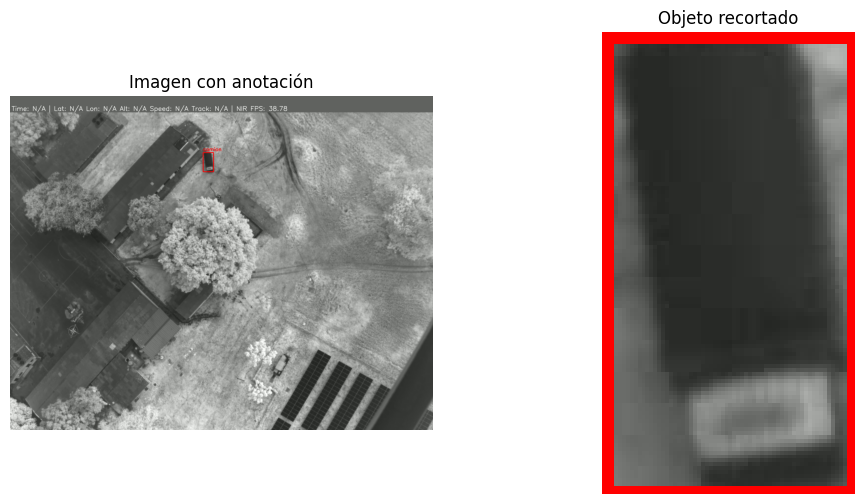

In [41]:
import json
import cv2
import matplotlib.pyplot as plt
import os

# Ruta al JSON
json_path = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\formato_coco\result.json"

# Carpeta donde están tus imágenes (ajústala)
images_dir = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\formato_coco\images"

# Cargar JSON
with open(json_path, "r") as f:
    coco = json.load(f)

images = {img["id"]: img for img in coco["images"]}
annotations = coco["annotations"]
categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Iterar por anotaciones
for ann in annotations:
    img_info = images[ann["image_id"]]
    img_path = os.path.join(images_dir, os.path.basename(img_info["file_name"]))
    
    # Cargar imagen
    img = cv2.imread(img_path)
    if img is None:
        print(f"No se encontró la imagen: {img_path}")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Extraer bbox
    x, y, w, h = ann["bbox"]
    x, y, w, h = int(x), int(y), int(w), int(h)
    
    # Dibujar rectángulo
    label = categories[ann["category_id"]]
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 3)
    cv2.putText(img_rgb, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 
                1, (255, 0, 0), 2, cv2.LINE_AA)
    
    # Recortar objeto
    cropped = img_rgb[y:y+h, x:x+w]
    
    # Mostrar resultados
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Imagen con anotación")
    plt.imshow(img_rgb)
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.title("Objeto recortado")
    plt.imshow(cropped)
    plt.axis("off")
    
    plt.show()


In [42]:
import json
import cv2
import os

# Ruta al JSON
json_path = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\formato_coco\result.json"

# Carpeta donde están tus imágenes
images_dir = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\formato_coco\images"

# Carpeta de salida
output_dir = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection"
os.makedirs(output_dir, exist_ok=True)

# Cargar JSON
with open(json_path, "r") as f:
    coco = json.load(f)

images = {img["id"]: img for img in coco["images"]}
annotations = coco["annotations"]
categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Contadores para nombres de archivos
counters = {cat_id: 0 for cat_id in categories.keys()}

# Iterar por anotaciones
for ann in annotations:
    img_info = images[ann["image_id"]]
    img_path = os.path.join(images_dir, os.path.basename(img_info["file_name"]))
    
    # Cargar imagen
    img = cv2.imread(img_path)
    if img is None:
        print(f"No se encontró la imagen: {img_path}")
        continue
    
    # Extraer bbox
    x, y, w, h = ann["bbox"]
    x, y, w, h = int(x), int(y), int(w), int(h)
    
    # Recortar objeto
    cropped = img[y:y+h, x:x+w]
    if cropped.size == 0:
        continue
    
    # Obtener clase
    label = categories[ann["category_id"]]
    
    # Crear carpeta de clase
    class_dir = os.path.join(output_dir, label)
    os.makedirs(class_dir, exist_ok=True)
    
    # Guardar con nombre único
    counters[ann["category_id"]] += 1
    filename = f"{label}_{counters[ann['category_id']]:04d}.png"
    save_path = os.path.join(class_dir, filename)
    cv2.imwrite(save_path, cropped)

print("✅ Recortes guardados en carpetas por clase.")


✅ Recortes guardados en carpetas por clase.


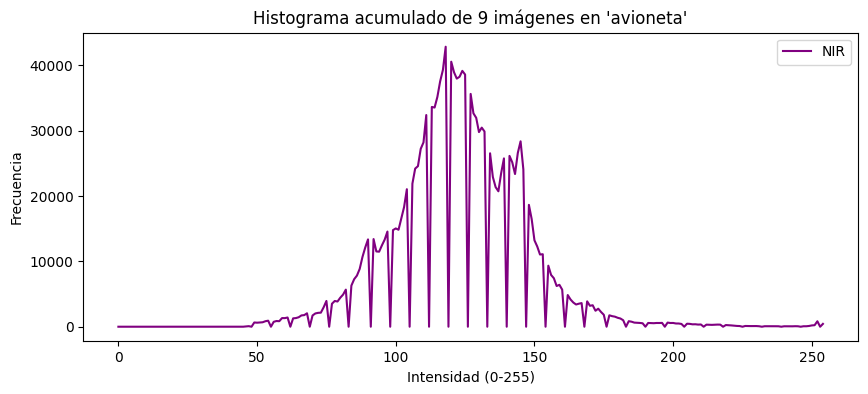

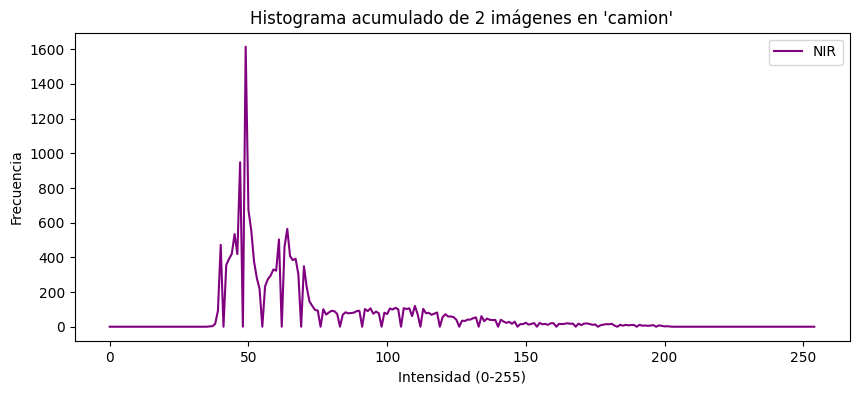

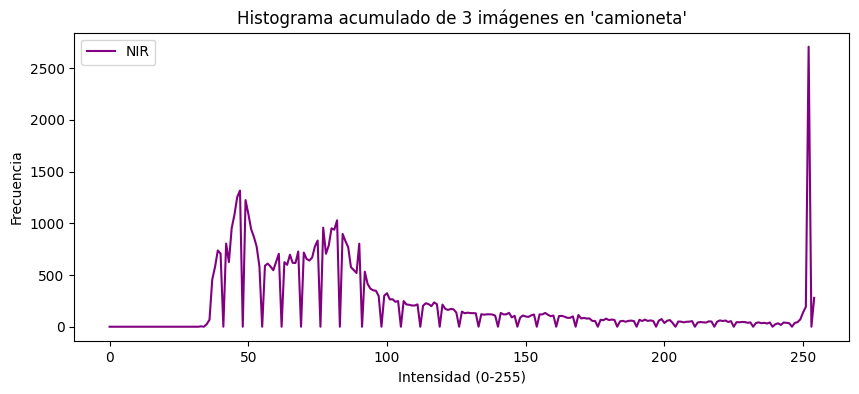

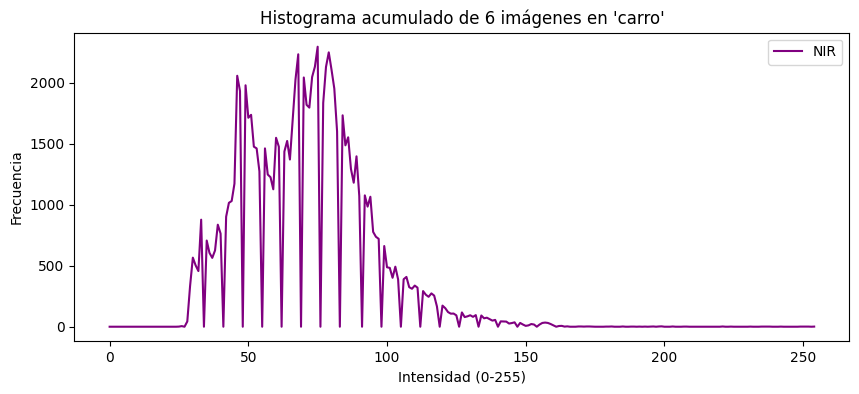

In [57]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def calcular_histograma_acumulado(carpeta, num_bins=255):
    # Inicializar histograma acumulado
    hist_nir = np.zeros((num_bins,), dtype=np.float32)

    # Listar imágenes
    imagenes = [f for f in os.listdir(carpeta) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

    for img_name in imagenes:
        img_path = os.path.join(carpeta, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

        if img is None:
            continue

        # Si es a color, convertir a escala de grises (equivalente a NIR en tu caso)
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Calcular histograma
        hist = cv2.calcHist([img], [0], None, [num_bins], [0, 255]).flatten()
        hist_nir += hist

    return hist_nir, len(imagenes)


def graficar_histograma(hist_nir, nombre_carpeta, num_imgs):
    plt.figure(figsize=(10, 4))
    plt.title(f"Histograma acumulado de {num_imgs} imágenes en '{nombre_carpeta}'")
    plt.xlabel("Intensidad (0-255)")
    plt.ylabel("Frecuencia")

    plt.plot(hist_nir, color="purple", label="NIR", drawstyle="default")

    plt.legend()
    plt.show()


def procesar_carpeta_principal(carpeta_principal):
    subcarpetas = [os.path.join(carpeta_principal, d) for d in os.listdir(carpeta_principal) if os.path.isdir(os.path.join(carpeta_principal, d))]

    for sub in subcarpetas:
        hist_nir, num_imgs = calcular_histograma_acumulado(sub)
        graficar_histograma(hist_nir, os.path.basename(sub), num_imgs)


# === USO ===
carpeta_principal = "E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\clases"
procesar_carpeta_principal(carpeta_principal)


In [59]:
import os
import cv2
import numpy as np

def calcular_histograma_acumulado(carpeta, num_bins=256):
    hist_nir = np.zeros((num_bins,), dtype=np.float64)
    imagenes = sorted([f for f in os.listdir(carpeta)
                       if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))])

    for img_name in imagenes:
        img_path = os.path.join(carpeta, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        if img is None:
            continue

        # Convertir a gris si es RGB
        if len(img.shape) == 3:
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            img_gray = img

        hist = cv2.calcHist([img_gray], [0], None, [num_bins], [0, 256]).flatten()
        hist_nir += hist

    return hist_nir, len(imagenes)


def mostrar_intensidades_cero(carpeta_principal):
    subcarpetas = sorted([os.path.join(carpeta_principal, d)
                          for d in os.listdir(carpeta_principal)
                          if os.path.isdir(os.path.join(carpeta_principal, d))])

    for sub in subcarpetas:
        hist_nir, n_imgs = calcular_histograma_acumulado(sub)
        intensidades_cero = np.where(hist_nir == 0)[0]  # índices donde hist=0

        print(f"\n📂 Carpeta: {os.path.basename(sub)}")
        print(f"   Imágenes procesadas: {n_imgs}")
        print(f"   Intensidades con frecuencia 0 ({len(intensidades_cero)} bins):")
        print(f"   {intensidades_cero.tolist()}")


# === USO ===
if __name__ == "__main__":
    carpeta_principal = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\clases"  # 🔹 cámbiala
    mostrar_intensidades_cero(carpeta_principal)



📂 Carpeta: avioneta
   Imágenes procesadas: 9
   Intensidades con frecuencia 0 (75 bins):
   [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 48, 55, 62, 69, 76, 83, 91, 98, 105, 112, 119, 126, 133, 140, 147, 154, 161, 168, 176, 183, 190, 197, 204, 211, 218, 225, 232, 239, 246, 253]

📂 Carpeta: camion
   Imágenes procesadas: 2
   Intensidades con frecuencia 0 (112 bins):
   [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 41, 48, 55, 62, 69, 76, 83, 91, 98, 105, 112, 119, 126, 133, 140, 147, 154, 161, 168, 176, 183, 190, 197, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254,

In [ ]:
vedai_images = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\dataset_VEDAI\Vehicules1024"
vedai_annotatios = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\dataset_VEDAI\Annotations1024"


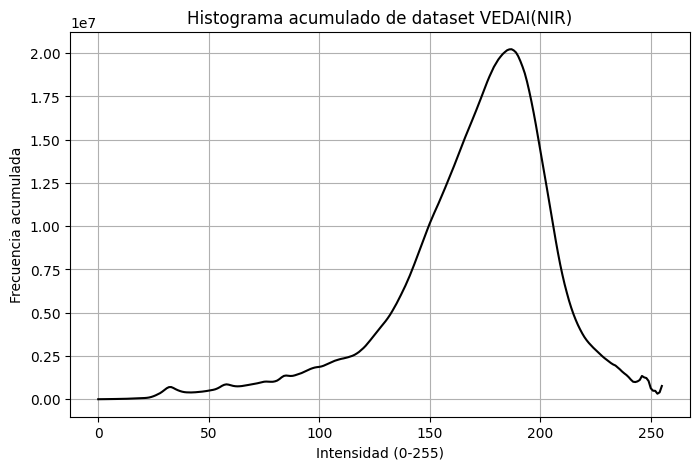

📂 Carpeta procesada: E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\dataset_VEDAI\Vehicules1024
   Imágenes NIR procesadas: 1268
   Intensidades con frecuencia 0 (0 bins):
   []


In [76]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def histogramas_nir(ruta_imagenes):
    # Listar solo imágenes NIR
    imagenes = sorted([f for f in os.listdir(ruta_imagenes) if f.endswith("_ir.png")])
    
    # Inicializar histograma acumulado
    hist_acumulado = np.zeros((256,), dtype=np.float32)
    
    # Procesar cada imagen NIR
    for img_file in imagenes:
        img_path = os.path.join(ruta_imagenes, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Solo un canal
        
        if img is None:
            print(f"No se pudo leer {img_file}")
            continue
        
        # Histograma de la imagen
        hist = cv2.calcHist([img], [0], None, [256], [0, 256])
        hist = hist.flatten()
        
        # Acumular
        hist_acumulado += hist
    
    # Encontrar intensidades con frecuencia 0
    intensidades_cero = np.where(hist_acumulado == 0)[0].tolist()
    
    # Mostrar histograma acumulado
    plt.figure(figsize=(8,5))
    plt.plot(hist_acumulado, color="black")
    plt.title("Histograma acumulado de dataset VEDAI(NIR)")
    plt.xlabel("Intensidad (0-255)")
    plt.ylabel("Frecuencia acumulada")
    plt.grid(True)
    plt.show()
    
    print(f"📂 Carpeta procesada: {ruta_imagenes}")
    print(f"   Imágenes NIR procesadas: {len(imagenes)}")
    print(f"   Intensidades con frecuencia 0 ({len(intensidades_cero)} bins):")
    print(f"   {intensidades_cero}")
    
    return hist_acumulado, intensidades_cero

# Ejemplo de uso
vedai_images = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\dataset_VEDAI\Vehicules1024"
hist_acum, intensidades_cero = histogramas_nir(vedai_images)


In [ ]:
import os
import cv2

def recortar_imagenes(ruta_entrada, ruta_salida, recorte_superior=100):
    """
    Recorta los primeros `recorte_superior` píxeles de todas las imágenes de la carpeta `ruta_entrada`
    y guarda las imágenes procesadas en `ruta_salida`.
    """
    # Crear carpeta de salida si no existe
    os.makedirs(ruta_salida, exist_ok=True)

    # Listar imágenes
    imagenes = [f for f in os.listdir(ruta_entrada) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.bmp'))]

    for img_file in imagenes:
        img_path = os.path.join(ruta_entrada, img_file)
        img = cv2.imread(img_path)

        if img is None:
            print(f"⚠ No se pudo leer {img_file}")
            continue

        # Recortar (eliminar los primeros `recorte_superior` píxeles en altura)
        img_recortada = img[recorte_superior:, :]

        # Guardar en la carpeta de salida
        out_path = os.path.join(ruta_salida, img_file)
        cv2.imwrite(out_path, img_recortada)

    print(f"✅ Recorte completado. Imágenes guardadas en: {ruta_salida}")


# Ejemplo de uso:
ruta_entrada = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\frames_objetos"
ruta_salida = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\imagenes_recortadas"
recortar_imagenes(ruta_entrada, ruta_salida, recorte_superior=100)
r_imagenes_recortadas = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\imagenes_recortadas"
hist_acum, intensidades_cero = hist_acum, intensidades_cero = histogramas_nir(r_imagenes_recortadas)



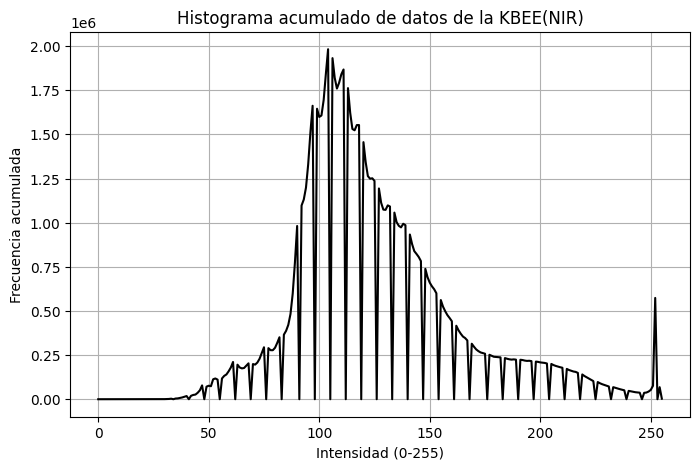

📂 Carpeta: E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\imagenes_recortadas
   Imágenes procesadas: 19
   Intensidades con frecuencia 0 (57 bins):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 27, 34, 41, 48, 55, 62, 69, 76, 83, 91, 98, 105, 112, 119, 126, 133, 140, 147, 154, 161, 168, 176, 183, 190, 197, 204, 211, 218, 225, 232, 239, 246, 253]


In [75]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def histograma_acumulado_carpeta(ruta_carpeta):
    """
    Calcula y grafica el histograma acumulado de todas las imágenes en la carpeta.
    Funciona para imágenes en escala de grises.
    """
    # Inicializar histograma acumulado
    hist_acumulado = np.zeros((256,), dtype=np.float32)
    
    # Listar imágenes válidas
    imagenes = [f for f in os.listdir(ruta_carpeta) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.bmp'))]

    if not imagenes:
        print("⚠ No se encontraron imágenes en la carpeta.")
        return None, None
    
    # Procesar imágenes
    for img_file in imagenes:
        img_path = os.path.join(ruta_carpeta, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"⚠ No se pudo leer {img_file}")
            continue
        
        # Calcular histograma de la imagen
        hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
        hist_acumulado += hist

    # Graficar histograma acumulado
    plt.figure(figsize=(8,5))
    plt.plot(hist_acumulado, color="black")
    plt.title("Histograma acumulado de datos de la KBEE(NIR)")
    plt.xlabel("Intensidad (0-255)")
    plt.ylabel("Frecuencia acumulada")
    plt.grid(True)
    plt.show()
    
    # Intensidades que nunca aparecen
    intensidades_cero = np.where(hist_acumulado == 0)[0].tolist()
    
    print(f"📂 Carpeta: {ruta_carpeta}")
    print(f"   Imágenes procesadas: {len(imagenes)}")
    print(f"   Intensidades con frecuencia 0 ({len(intensidades_cero)} bins):")
    print(intensidades_cero)
    
    return hist_acumulado, intensidades_cero


# Ejemplo de uso:
ruta = r"E:\MACHINE LEARNING\AVANZADO 1\VSFOLDER A1 PROYECT\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\Own_Data_Exploration\object detection\imagenes_recortadas"
hist_acum, intensidades_cero = histograma_acumulado_carpeta(ruta)
